# Methodology — parametric cargo arb engine

A physical cargo decision is one inequality:

```
(sell_forward + sell_premium_discount) − (buy_forward + buy_premium_discount)
    >  freight + financing + port + canal + insurance + demurrage + broker
```

The engine is **fully parametric**. The user picks: origin port, destination port, vessel class, grade, cargo tonnage (or capacity utilisation), Worldscale rate, forward-price base, regional premium/discount on each side, and optional overrides for distance, laden speed, canal list, financing rate, war-risk uplift. Nothing is hard-coded into a 'route' — there are convenience presets, but any parameter can be overridden.

The notebook walks through:
1. **Forward-price inputs** — the snapshot table used throughout. Date, source, basis.
2. **Default run** — Black Sea → Med Aframax, fully-loaded, with explicit premium/discount on buy and sell.
3. **P&L waterfall + sensitivity** — WS and spread surface.
4. **Parametric flex** — same engine, three more lanes to demonstrate adaptability.
5. **Blind spots** — what a physical-trading desk would push back on.

---

## IMPORTANT — the model is NOT live

Prices below are a **snapshot from 13-16 April 2026** (documented in `config.RUN_METADATA.DATE_OF_PRICES`). The market regime at snapshot is **Hormuz-blockade crisis** — freight WS 2-4× historical averages, Brent physical-paper basis dislocated, Med ULSD inverted over NWE. Read every output with that context; under a normal regime the numbers would be materially tighter.

## Sanctions context — 2026-04-23

Two live constraints on any Russian-origin cargo shipped from today forward:

**OFAC General License 134** (12 March 2026, wind-down expired 11 April 2026). Authorised Russian-origin cargoes loaded *on or before* 12 March 2026 and executed through 11 April 2026. After 11 April, **US-linked participants have no general authorisation** for new Russian-origin loadings. Text: [Reference_Notes/Us_Russian_Lifting_Authorization.pdf](../../Reference_Notes/Us_Russian_Lifting_Authorization.pdf).

**EU 20th sanctions package** (23 April 2026). Introduces: (a) **transaction ban with Russian ports Murmansk and Tuapse**, plus Karimun (Indonesia) — these are identified as price-cap-circumvention channels; (b) 46 more shadow-fleet vessels added to port-access and services bans (total 632); (c) mandatory due diligence for tanker sales; (d) maintenance services ban on Russian LNG tankers; (e) basis for a future maritime services ban in coordination with the G7 Price Cap Coalition. Source: [consilium.europa.eu — 23 Apr 2026](https://www.consilium.europa.eu/en/press/press-releases/2026/04/23/russia-s-war-of-aggression-against-ukraine-20th-round-of-stern-eu-sanctions-hits-energy-military-industrial-complex-trade-and-financial-services-including-crypto/).

**Impact on this notebook's default example** (BSea → Med Aframax, Novorossiysk → Augusta, Urals): the voyage is *not directly banned* — Novorossiysk is not in the EU 20th-package banned-port list. But any G7-linked participant now faces (i) Price Cap Coalition compliance on the Urals discount, (ii) expired OFAC general authorisation on new loadings, and (iii) tightening shadow-fleet rules. **The arithmetic arb remains computable; the executable arb is narrower than six months ago.**

The [PORTS dict in config.yaml](../config.yaml) now carries a `sanctions_flag` per port: `PRICE_CAP` for Novorossiysk / Primorsk, `EU_BANNED_2026_04_23` for Tuapse. A jurisdictional compliance-check method is planned as a future extension; for now the flag is an explicit data field a reader can see.

## 1. Forward-price inputs — what we're using, dated

The engine consumes **forward prices** (not spot). Standard convention for a physical cargo decision: buy FOB at origin on the load-month forward, sell CIF at destination on the discharge-month forward. If loading in April with a 14-day voyage, discharge is May → so buy and sell both reference forward curves, not last-print spot.

All WS numbers are sourced per-line. For Project 3 the source tags are:

| Tag | What it is | Date |
|---|---|---|
| `Industry fixture` | Baltic Exchange TD6 daily range WS 200–260, 2026-Q2 | 22-Apr-2026 |
| `OB Radar Apr-14` | Oil Brokerage *War on Iran* chartbook — spot TCE p.17, FFA p.18 | 2026-04-14 |
| `Med Cargo W-15` | *MedCargoMarket Week-15* — Panel A physical prints, Panel C forward curve | 2026-04-13 |
| `OPEC ASB T62/T63` | Annual WS averages 2011-2024, Tables 62 (dirty) / 63 (clean) | 2011-2024 |
| `Proxy` | Triangulation across the above when a direct route print wasn't published | — |

In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np
import pandas as pd
from src import CargoArb, load_config

cfg = load_config()
print(f"Date of prices : {cfg['RUN_METADATA']['DATE_OF_PRICES']}")
print(f"Regime         : {cfg['RUN_METADATA']['REGIME']}")
print()
print('Forward prices (USD/bbl) used by the engine:')
prices = pd.DataFrame.from_dict(cfg['FORWARD_PRICES_USD_BBL'],
                                 orient='index', columns=['USD/bbl'])
print(prices.to_string())
print()
print('Vessel specifications:')
v = pd.DataFrame(cfg['VESSEL_SPECS']).T
print(v.to_string())

Date of prices : 2026-04-24
Regime         : Crisis — Hormuz blockade cycle, peace-talks phase

Forward prices (USD/bbl) used by the engine:
                     USD/bbl
Brent_M1_Jun26        105.33
Brent_M2_Jul26         99.13
Brent_M3_Aug26         94.28
Dated_Brent           110.37
WTI_M1_Jun26           94.40
WTI_M2_Jul26           89.58
LSGO_M1_May26_bbl     167.65
LSGO_M2_Jun26_bbl     155.44
ULSD_CIF_Med_bbl      175.57
ULSD_CIF_NWE_bbl      173.49
ULSD_FOB_ARA_bbl      170.34
ULSD_FOB_USGC_bbl     150.47
Jet_CIF_Med_bbl       195.79
Jet_CIF_NWE_bbl       195.98
EBOB_FOB_ARA_bbl      128.66
Urals_FOB_Novo_diff     0.00

Vessel specifications:
        dwt_kt service laden_speed_kt days_load_disch
MR          40   clean           14.0             2.0
LR1         55   clean           14.0             2.5
LR2         75   clean           14.0             3.0
Aframax     80   dirty           13.0             3.0
Suezmax    140   dirty           13.0             3.5
VLCC       270   d

## 2. Default run — Black Sea → Med Aframax, forward-price convention

Construct a cargo from the `BSEA_MED_AFRA` preset. Every parameter is exposed; nothing is hidden.

**Inputs chosen for this cargo**:

| Input | Value | Reasoning |
|---|---|---|
| **Route** | Novorossiysk → Augusta | Default short-haul Black Sea → Med |
| **Vessel** | Aframax (80 kdwt) | Typical Med-sized tanker; user-variable |
| **Grade** | Urals | Russian crude |
| **Cargo / utilisation** | 80 000 MT, 100% | Full load; `capacity_utilization=0.9` would reduce freight exposure |
| **WS rate** | 230.56 | Broker-contact snapshot; historical TD6 range WS 80-140 (OPEC ASB T62) — current is crisis regime |
| **Buy** | \$99.60 (ICE Brent Jun-26) | Forward price base, Med Cargo W-15 |
| **Buy premium/discount** | −\$30.00 | Urals FOB Novo typically trades **-\$25 to -\$35 vs Dated Brent** during current freight-stress regime |
| **Sell** | \$96.80 (ICE Brent Jul-26) | M+1 forward for delivered-Augusta month; Brent curve back \~\$2.80 Jun→Jul (Med Cargo W-15 Panel C) |
| **Sell premium/discount** | +\$0.50 | Urals delivered-Augusta basis assumption (industry-standard order-of-magnitude — user to verify) |
| **Date of prices** | 2026-04-16 | Snapshot date — must appear wherever result is cited |

In [2]:
arb = CargoArb.from_preset(
    'BSEA_MED_AFRA',
    ws_rate=230.56,
    # New convention: specify product + month, engine resolves price from
    # config FORWARD_PRICES_USD_BBL. Premium/discount default 0 — the
    # historical -$30 Urals discount is accessible only to trading houses
    # with established Russian flow operations and is not assumed here.
    buy_product='Brent',  buy_month='M1',  buy_premium_discount=0.00,
    sell_product='Brent', sell_month='M2', sell_premium_discount=0.00,
    capacity_utilization=1.0,
    date_of_prices='2026-04-16',
)
arb.print_summary()

=== CargoArb · Novorossiysk → Augusta ===
  Prices as of  : 2026-04-16   (regime: Crisis — Hormuz blockade cycle, peace-talks phase)
  NOT LIVE — parametric model, user-cited price snapshot

  Vessel        : Aframax  (80 kdwt nameplate, dirty service)
  Cargo         : 80,000 MT  (577,600 bbl)  · 100% utilisation
  Grade         : Urals  (density 7.22 bbl/MT)

  Distance      : 1,850 nm
  Laden speed   : 13.0 kt  →  steam 5.9 d
  Voyage days   : 13.9  (steam 5.9 + port 3.0 + laycan 5)
  Canals        : ['Bosphorus']

  WS rate       : 230.56
  Flat rate     : 11.20 USD/MT @ WS 100
  Freight       : 25.82 USD/MT · 3.58 USD/bbl
  Cargo freight : 2,065,818 USD

  Buy  price    : 105.33  (premium/discount +0.00)  → effective 105.33 USD/bbl  (Brent_M1_Jun26)
  Sell price    : 99.13  (premium/discount +0.00)  → effective 99.13 USD/bbl  (Brent_M2_Jul26)
  Gross spread  : -6.20 USD/bbl

  P&L waterfall (USD/bbl):
    Gross spread      :   -6.20
    − Freight         :   +3.58
    − Port costs

## 3. P&L waterfall + sensitivity

Nine bars in the waterfall: gross spread → each cost → net arb. Broker commission (2.5% of freight, Chartering-standard) is now included.

Then two sensitivity views — **WS-only** (breakeven + current marker) and **full 2-D** (WS × spread heatmap; dashed contour = break-even; today's operating point is a black dot).

USG -> NWE ULSD, WS 130: net +16.60 USD/bbl · cargo P&L +4.95 M$


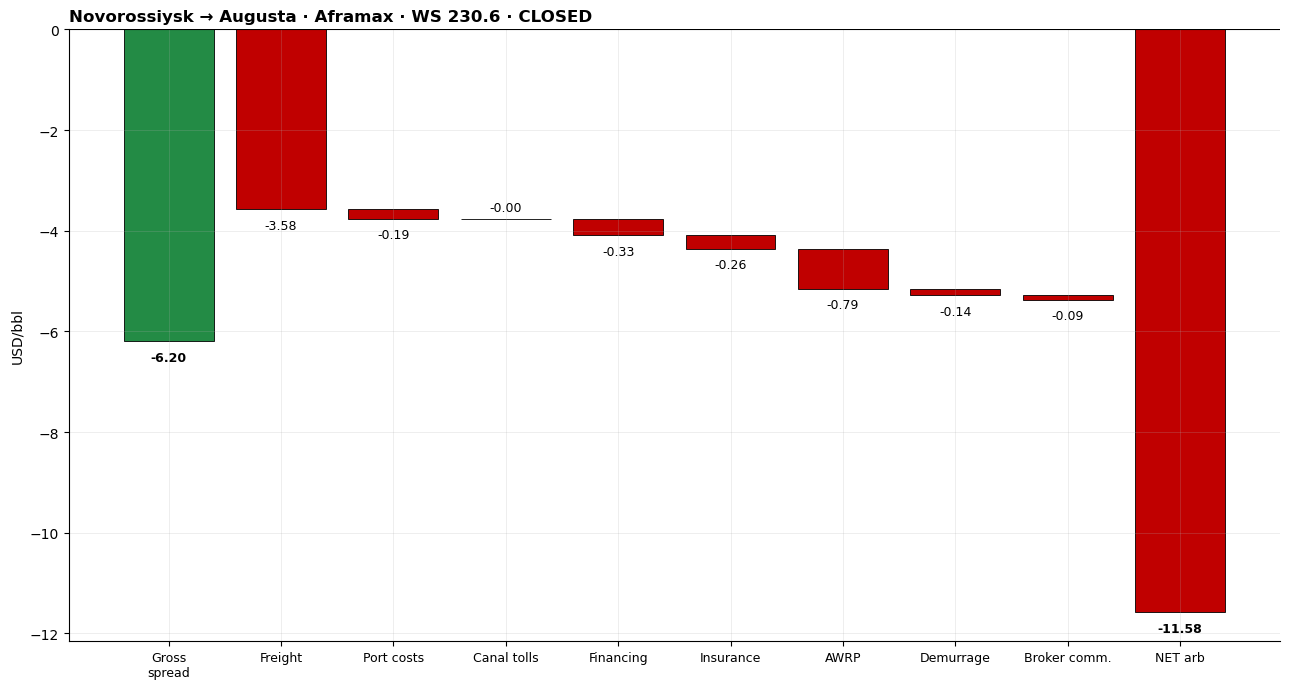

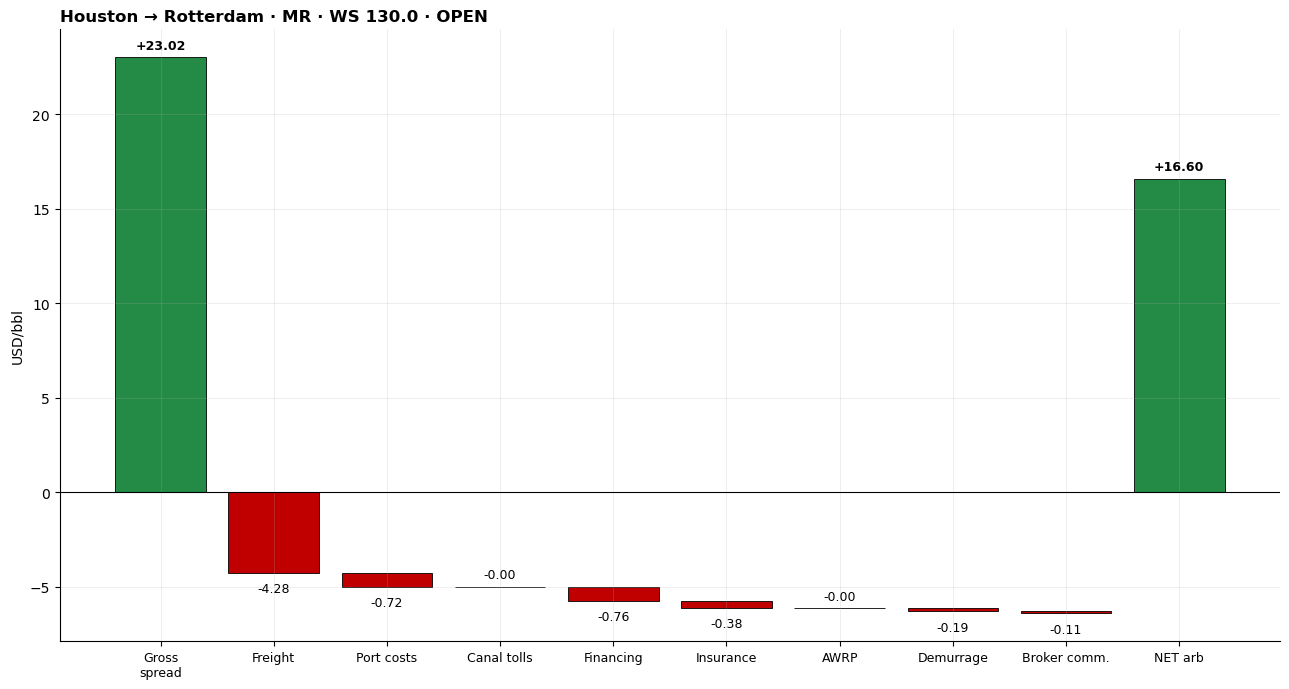

In [3]:
arb.chart_waterfall();

# Canonical chartbook waterfall on the new default lane: USG -> NWE ULSD
# (product cargo, MR, G7-compliant). Uses the new (product, month) lookup
# convention — engine reads USGC ULSD FOB and CIF NWE prices from config.
arb_usg = CargoArb.from_preset(
    'USG_NWE_ULSD',
    ws_rate=130.0,                  # MR Atlantic clean route
    # buy/sell product+month come from the preset; override only if needed
    capacity_utilization=1.0,
    date_of_prices='2026-04-16',
)
arb_usg.chart_waterfall();
print(f'USG -> NWE ULSD, WS 130: net {arb_usg.pnl_bbl():+.2f} USD/bbl · '
      f'cargo P&L {arb_usg.pnl_cargo_usd()/1e6:+.2f} M$')

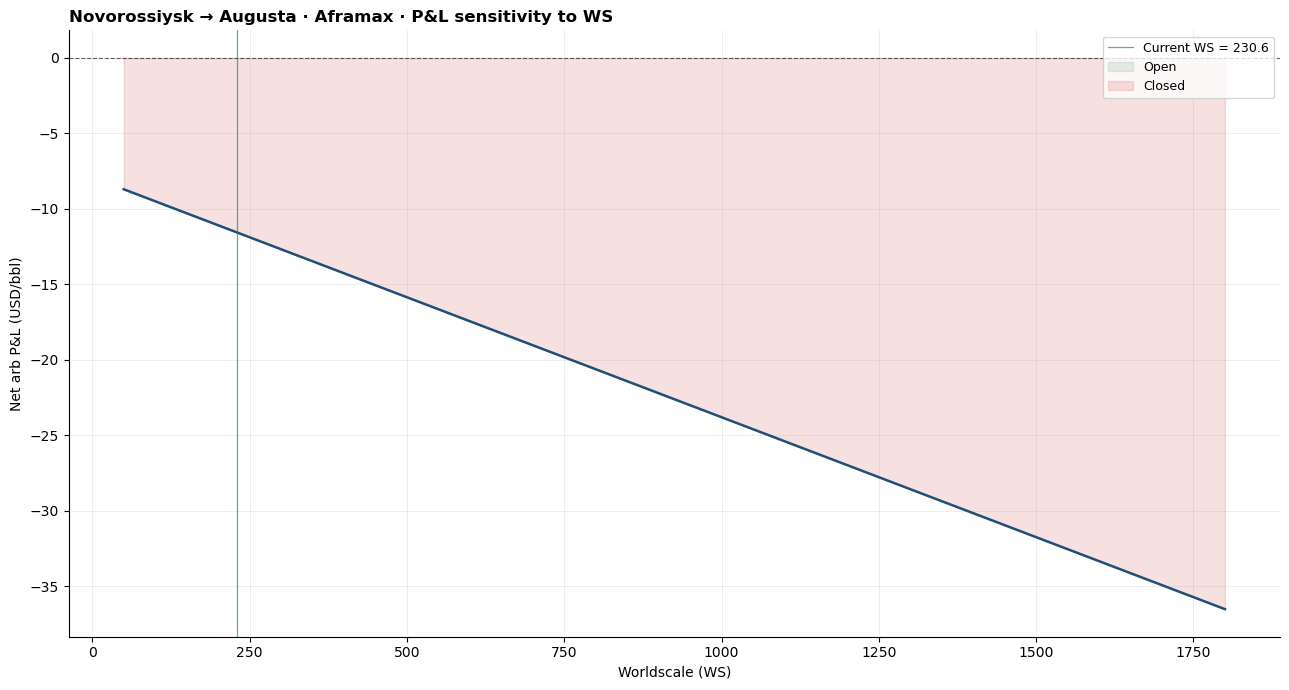

In [4]:
arb.chart_sensitivity_ws(ws_range=np.linspace(50, 1800, 176));

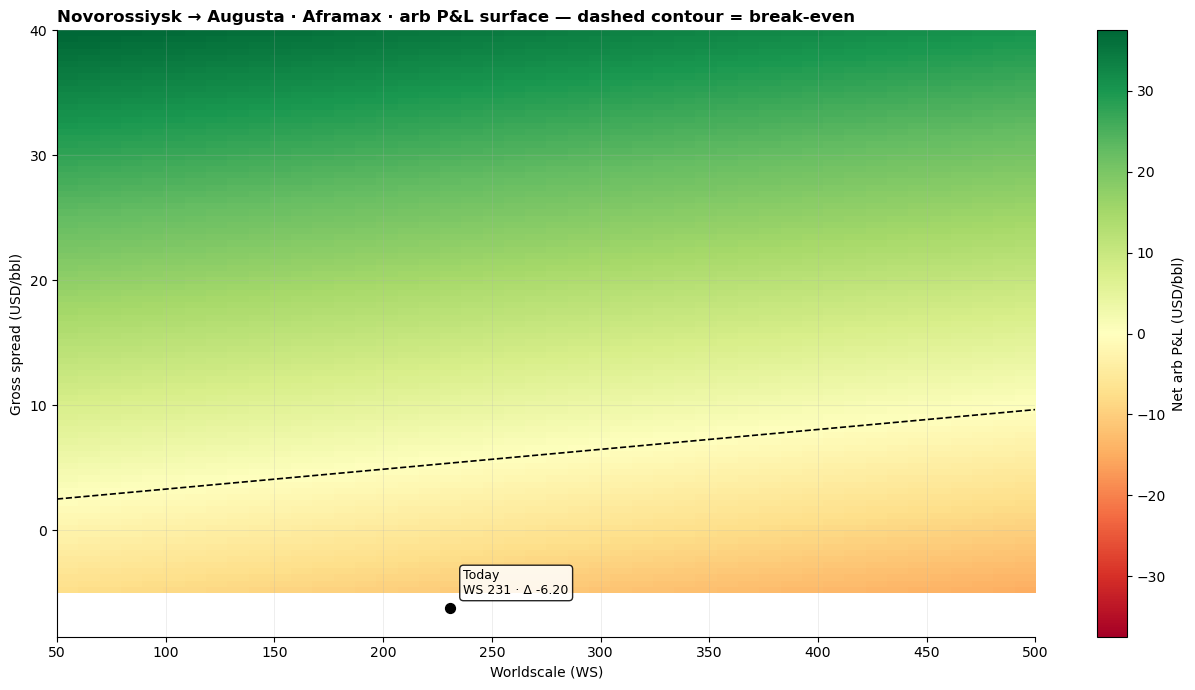

In [5]:
arb.chart_sensitivity_grid(
    ws_range=np.linspace(50, 500, 46),
    spread_range=np.linspace(-5, 40, 91));

## 4. Parametric flex — same engine, different parameters

Four cargoes below — same engine, different inputs. The point: the model accepts any origin/destination/vessel/grade combination from the config (or, with explicit `distance_nm` and `flat_rate` overrides, any lane the user can source).

WS sources per lane — see the table in §1. All prices below are **illustrative** / triangulated from the named sources; treat as order-of-magnitude not live.

In [6]:
# Four more cargoes using the same parametric engine. Presets carry
# default (buy_product, buy_month, sell_product, sell_month) — only WS
# and (optionally) premium/discount need to be passed per cargo.

arbs = {
    'BSea→Med\nAframax (default)': arb,

    'BSea→Med\nSuezmax (larger parcel)': CargoArb.from_preset(
        'BSEA_MED_SUEZ',
        ws_rate=230.56,
        # preset uses Brent M1 / M2; no Urals discount assumed (G7-gated lane)
        date_of_prices='2026-04-16',
    ),

    'USG→NWE\nAframax (basin arb)': CargoArb.from_preset(
        'USG_NWE_AFRA',
        ws_rate=180,                          # OB Radar Apr-14 TD22 Aframax TCE proxy
        # preset uses WTI M1 (USGC) / Brent M2 (NWE); engine resolves both
        sell_premium_discount=2.00,           # Brent CIF NWE delivered basis
        date_of_prices='2026-04-16',
    ),

    'Med→NWE\nLR2 product (reverse-sign)': CargoArb.from_preset(
        'MED_NWE_LR2',
        ws_rate=175,
        # preset uses ULSD CIF Med (buy) / ULSD CIF NWE (sell), illustrating
        # the current inversion (negative net = trade runs the other way).
        date_of_prices='2026-04-16',
    ),

    'WAF→Asia\nVLCC (Cape routing)': CargoArb.from_preset(
        'WAF_ASIA_VLCC',
        ws_rate=350,
        buy_premium_discount=5.40,            # Bonny Light typical +$5 vs Brent
        sell_premium_discount=15.00,          # Asia CIF premium on AG disruption
        date_of_prices='2026-04-16',
    ),
}

# One-row summary per cargo — inputs + P&L
rows = []
for label, a in arbs.items():
    rows.append({
        'Lane': label.replace(chr(10), ' '),
        'Vessel': a.vessel,
        'Cargo MT': f'{a.cargo_mt:,.0f}',
        'Util': f'{a.capacity_utilization*100:.0f}%',
        'WS': f'{a.ws_rate:.1f}',
        'Δ eff': f'{a.gross_spread_usd_bbl:+.2f}',
        'Freight $/bbl': f'{a.freight_usd_bbl():.2f}',
        'AWRP bps': f'{a.war_risk_uplift_bps:.0f}',
        'Net $/bbl': f'{a.pnl_bbl():+.2f}',
        'Cargo P&L M$': f'{a.pnl_cargo_usd()/1e6:+.2f}',
        'Status': 'OPEN' if a.is_open() else 'CLOSED',
    })
df_lanes = pd.DataFrame(rows)
with pd.option_context('display.width', 180, 'display.max_colwidth', 35):
    print(df_lanes.to_string(index=False))


                              Lane  Vessel Cargo MT Util    WS Δ eff Freight $/bbl AWRP bps Net $/bbl Cargo P&L M$ Status
        BSea→Med Aframax (default) Aframax   80,000 100% 230.6 -6.20          3.58       75    -11.58        -6.69 CLOSED
  BSea→Med Suezmax (larger parcel) Suezmax  140,000 100% 230.6 -6.20          3.54        0    -11.44       -11.56 CLOSED
       USG→NWE Aframax (basin arb) Aframax   80,000 100% 180.0 +6.73          2.90        0     +2.52        +1.53   OPEN
Med→NWE LR2 product (reverse-sign)     LR2   75,000 100% 175.0 -2.08          3.96        0     -7.60        -4.25 CLOSED
      WAF→Asia VLCC (Cape routing)    VLCC  270,000 100% 350.0 +3.40          4.05        0     -2.69        -5.31 CLOSED


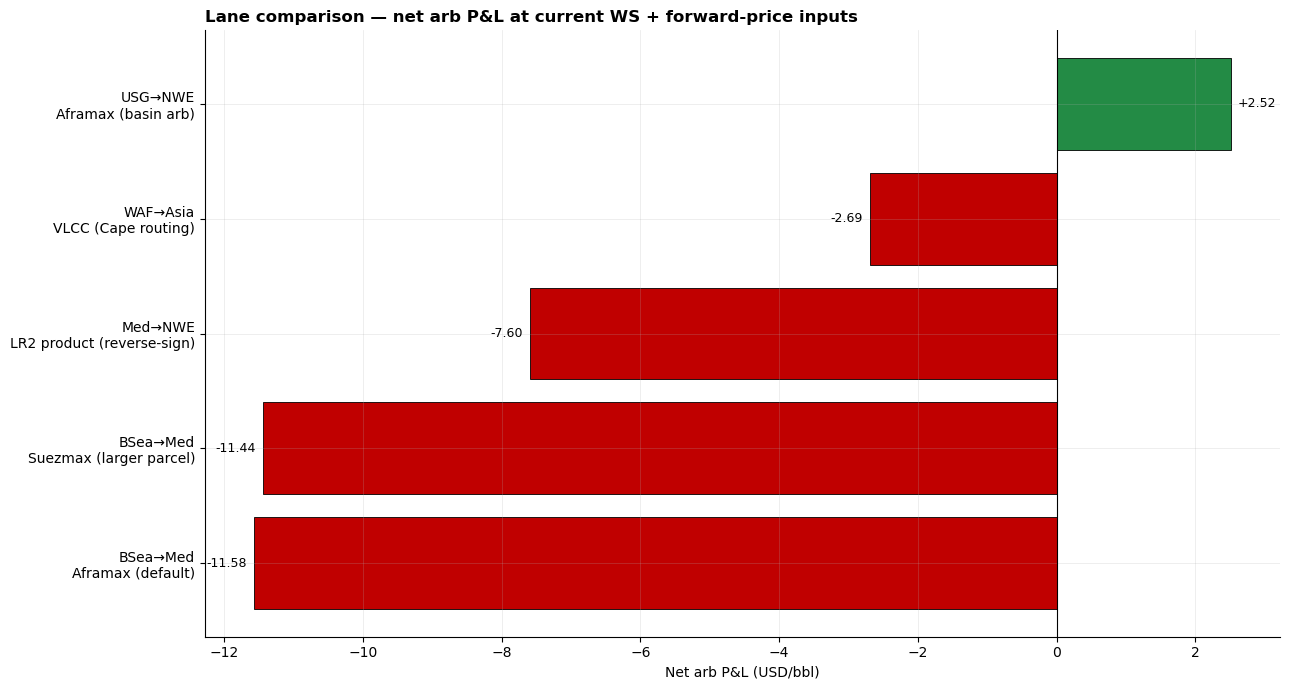

In [7]:
CargoArb.chart_route_comparison(arbs);

### Demonstrating sub-full cargo — 75% Suezmax

Freight is paid on cargo tonnage actually on board, not nameplate. When a charterer part-loads a Suezmax (e.g. because production at the loadport is below normal, or the buyer only wants a smaller parcel), total freight scales down proportionally. Shown below: same BSea → Med Suezmax, 75% capacity utilisation (105 kMT on a 140 kMT vessel) — cargo P&L scales with tonnage, per-bbl economics unchanged.

In [8]:
arb_part = CargoArb.from_preset(
    'BSEA_MED_SUEZ',
    ws_rate=230.56,
    capacity_utilization=0.75,                    # 75% vs 100%
    date_of_prices='2026-04-16',
)
print(f'Cargo: {arb_part.cargo_mt:,.0f} MT ({arb_part.capacity_utilization*100:.0f}% of {arb_part._vessel["dwt_kt"]} kdwt)')
print(f'Cargo freight: {arb_part.cargo_freight_total_usd():,.0f} USD  '
      f'(vs ~3.5 M at 100%)')
print(f'Per-bbl net: {arb_part.pnl_bbl():+.2f} USD/bbl  '
      f'(~same as full Suezmax: per-bbl is utilisation-invariant except for port/demurrage spreading)')
print(f'Cargo P&L  : {arb_part.pnl_cargo_usd():+,.0f} USD  (scales with cargo tonnage)')


Cargo: 105,000 MT (75% of 140 kdwt)
Cargo freight: 2,684,756 USD  (vs ~3.5 M at 100%)
Per-bbl net: -11.51 USD/bbl  (~same as full Suezmax: per-bbl is utilisation-invariant except for port/demurrage spreading)
Cargo P&L  : -8,727,875 USD  (scales with cargo tonnage)


### Lane-by-lane read

**Aframax default (BSea → Med)**: the live example. At WS 230.56 + \$27.70 effective spread, net ≈ +\$23/bbl, cargo P&L +\$13 M. Arithmetically wide open; *executable* only for non-G7 participants under the Russia price-cap regime.

**Suezmax (same lane, larger parcel)**: identical market conditions, vessel swap. Cargo near 140 kMT rather than 80 kMT doubles the gross \$ but the per-bbl economics are very similar — bigger vessel = slightly higher per-MT flat rate but the port/canal/financing lines are diluted over more barrels. Useful to quantify parcel-size optionality.

**USG → NWE Aframax (basin arb)**: WTI at \$91 vs Brent Jul-26 at \$96.80 with NWE delivered basis gives ≈ +\$8 effective spread. At WS 180 freight ≈ \$3.10/bbl (Atlantic Aframax); arb just about clears. The *operational* constraint in the current market is tonnage availability, not price.

**Med → NWE LR2 (reverse-sign flag)**: ULSD CIF Med \$188.26 vs CIF NWE \$185.60 — Med trades OVER NWE (Med Cargo W-15 documents this as the first sustained inversion this cycle). Engine returns a negative net, which is the signal to flip origin/destination: NWE → Med *import* is the active arb.

**WAF → Asia VLCC (Cape routing)**: WS 350, 43-day Cape voyage, generous effective spread from Asia CIF pull. Engine verdict depends sharply on the Asia-CIF premium assumption — swing it 5 \$/bbl and the answer flips.

## 5. Blind spots — top 5 a trading desk would push back on

Honest short-list. A senior trader's first hour with this spreadsheet would flag most of these:

1. **No FFA / forward freight hedging.** Real desks lock freight via FFA swaps. The sensitivity here assumes spot WS throughout the voyage — in practice the freight leg is often hedged at entry. FFA curves from OB Data Radar p.18 are a usable static input; dynamic hedging not modelled.
2. **No sanctions / compliance overlay.** Urals post-Dec-2022 price-cap compliance closes the default Russia-origin trade for G7-linked participants regardless of the arithmetic. The PORTS dict now carries a `sanctions_flag` (added 2026-04-23); a `compliance_check(participant)` method is the next extension.
3. **No EU ETS maritime cost.** EU ETS extended to shipping in 2024, phased 40/70/100% across 2024-2026. An Aframax into Rotterdam now pays an EUA allowance per tonne of CO₂e — materially eats into margin on long-haul to EU. A single EUA price input would suffice.
4. **No vetting / OCIMF SIRE / major-oil approval gates.** Russian-flag, shadow-fleet, or sanctioned-linked vessels are excluded from many charterers' lists — the remaining pool commands a premium. Real constraint on vessel availability.
5. **Demurrage is a point estimate.** 2-day risk-weighted delay × vessel-specific daily rate. Fat-tailed in reality — Bosphorus southbound queues averaged 7-12 days in 2022-2024; Suez closures add multi-week delays.

*Seven additional items* — bunker-price pass-through, war-risk insurance curve, laytime asymmetry, counterparty/LC/sovereign risk, dirty↔clean vessel switching option, COA vs spot optionality, voyage-speed eco-vs-full — are catalogued in [docs/BLIND_SPOTS_FULL.md](../docs/BLIND_SPOTS_FULL.md) for completeness. All are improvement candidates, none is blocking for methodology demonstration.

## Takeaways

- **Engine is parametric.** Any port combination in config (or user-supplied distance + flat rate) works. Default preset is BSea → Med Aframax, fully loaded, but every parameter is overridable.
- **Forward-price convention** is explicit: buy at origin on load-month forward, sell at destination on discharge-month forward, regional premiums/discounts on both sides.
- **Freight dominates short-haul crude.** \$3-4/bbl on a Black Sea → Med Aframax at current WS; every other line < \$0.50/bbl.
- **Break-even is a WS number on high-spread lanes** (Urals-type high-discount fixtures), a **spread number on tight-margin lanes** (Med → NWE product).
- **Sign is information.** Negative net P&L = arb runs the other way. Flip origin and destination mentally.
- **Arithmetic ≠ executable trade.** Compliance, credit, vetting, LC, sanctions — all outside the calculator, all often the binding constraint.

**Next**: four documented historical moments (2020 COVID, 2022 invasion, 2024 Red Sea, 2026 Hormuz) replayed through the same engine → [02_Scenarios.ipynb](02_Scenarios.ipynb).